<a href="https://colab.research.google.com/github/adilsher-dev/DEEP-LEARNING/blob/main/LayerDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf


In [3]:
image = Image.open("catsample.jpg").convert("L")


In [4]:
image = image.resize((256, 256))


In [5]:
image = np.array(image, dtype=np.float32) / 255.0

In [6]:
image = np.expand_dims(image, axis=(0, -1))

In [7]:
vertical_filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)


In [8]:
horizontal_filter = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

In [9]:
vertical_filter = vertical_filter.reshape(3, 3, 1, 1)
horizontal_filter = horizontal_filter.reshape(3, 3, 1, 1)


In [10]:
vertical_edges = tf.nn.conv2d(
    image,
    vertical_filter,
    strides=[1, 1, 1, 1],
    padding="SAME"
)

horizontal_edges = tf.nn.conv2d(
    image,
    horizontal_filter,
    strides=[1, 1, 1, 1],
    padding="SAME"
)

In [11]:
vertical_edges = vertical_edges.numpy().squeeze()
horizontal_edges = horizontal_edges.numpy().squeeze()

In [12]:
plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

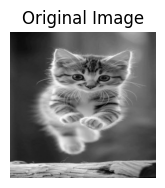

In [13]:
plt.subplot(1, 3, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

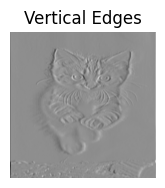

In [14]:
plt.subplot(1, 3, 2)
plt.imshow(vertical_edges, cmap="gray")
plt.title("Vertical Edges")
plt.axis("off")

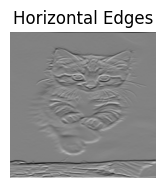

In [15]:
plt.subplot(1, 3, 3)
plt.imshow(horizontal_edges, cmap="gray")
plt.title("Horizontal Edges")
plt.axis("off")

plt.show()